# Week 5 - Expectation Maximization and Principal Component Analysis

Learning contents:

1. Mixture of Gaussians: Expectation-Maximization
    - Display results
    - Nearest Centroid-based classification
2. Principal Component Analysis
    - Generate data
    - Apply PCA
    - Display projection

## Dependencies

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import multivariate_normal, norm
from sklearn import datasets
from IPython.display import HTML

import seaborn as sns; sns.set(); sns.set_palette('bright')

## Generate Data

#### We use `iris` dataset from `sklearn` library

(<matplotlib.collections.PathCollection at 0x1348d91d0>,
 <matplotlib.legend.Legend at 0x133a8c110>)

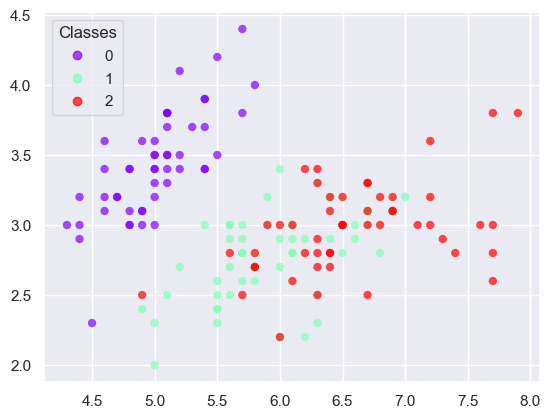

In [3]:
iris = datasets.load_iris()
iris_x = np.array(iris.data[:, :2])  # we only take the first two features.
iris_t = np.array(iris.target)

def plot_iris(legend=True, classes=iris_t, target=plt):
    scatter = target.scatter(iris_x[:, 0], iris_x[:, 1], c=classes, alpha=0.7, cmap='rainbow', edgecolor='none')
    if legend:
        legend = target.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
        return (scatter, legend)
    return (scatter, )

plot_iris()

## 1) Mixture of Gaussians: Expectation-Maximization

write a function `gaussian_mixture` that takes data point `x` (say, a vector in D-dimensional space), set of multivariate `means` and respective `covariances`, and `pis` (mixing coefficients as defined in a Gaussian mixture model) and should return PDF value of mixture model at the point x.

In [4]:
def gaussian_mixture(x, means, covariances, pis):
    pdf_value = 0
    for k in range(len(pis)):
        pdf_value += pis[k] * multivariate_normal.pdf(x, means[k], covariances[k])
    return pdf_value

write a function `expectation_maximization_gaussian` that takes initial mean vectors `mus_0`, initial covariance matrices `covariances_0`, initial mixing coefficient values `pis_0`, input data set `data_x` and a callback `on_step`.

The `on_step` is a function that takes current set of `mus`, corresponding `covariances` and `pis`, value of `log_likelihood` and list of class `predictions` for each point and should be called each iteration step. Remember that you do not need to define this function as it has already been defined in the later part of the code, you just need to call it after updating parameters in each iteration.

In [5]:
def expectation_maximization_gaussian(mus_0, covariances_0, pis_0, data_x, on_step):
    N, D = data_x.shape  # Number of data points and dimensions
    K = len(pis_0)  # Number of Gaussian components
    THRESHOLD = 0.005
    
    mus = np.copy(mus_0)
    covariances = np.copy(covariances_0)
    pis = np.copy(pis_0)
    
    prev_log_likelihood = -np.inf  # Initialize to negative infinity

    def gamma(n, k):
        return (pis[k] * multivariate_normal.pdf(data_x[n], mus[k], covariances[k])) / gaussian_mixture(data_x[n], mus, covariances, pis)

    while True:  # Will break out when condition met
        new_mu = [1 / np.sum([gamma(n, k) for n in range(N)]) * np.sum([gamma(n, k) * data_x[n] for n in range(N)], axis=0) for k in range(K)]
        
        new_sigma = [1 / np.sum([gamma(n, k) for n in range(N)]) * np.sum([gamma(n, k) * np.outer(data_x[n] - new_mu[k], data_x[n] - new_mu[k]) for n in range(N)], axis=0) for k in range(K)]
        
        N_k = [np.sum([gamma(n, k) for n in range(N)]) for k in range(K)]
        new_pis = [N_k[k] / N for k in range(K)]
        
        log_likelihood = np.sum([np.log(gaussian_mixture(data_x[n], new_mu, new_sigma, new_pis)) for n in range(N)])
        
        # Compute predictions
        predictions = [np.argmax([gamma(n, k) for k in range(K)]) for n in range(N)]
        
        # Call the callback function
        on_step(mus, covariances, pis, log_likelihood, predictions)
        
        # Check for convergence
        if np.abs(log_likelihood - prev_log_likelihood) < THRESHOLD:
            break
        
        # Update parameters for next iteration
        mus = new_mu
        covariances = new_sigma
        pis = new_pis
        prev_log_likelihood = log_likelihood


### 1.1) Display results

In [6]:
def plot_gaussian_mixtures(mus, covariances, pis, data, classes, cmap='rainbow', target=plt):
    
    lx = min(data[:, 0])
    rx = max(data[:, 0])
    by = min(data[:, 1])
    uy = max(data[:, 1])

    x, y = np.mgrid[lx:rx:.01, by:uy:.01]
    pos = np.dstack((x, y))
    
    probabilities = list(map(
        lambda x: gaussian_mixture(x, mus, covariances, pis),
        pos
    ))
    
    target.contour(x, y, probabilities, cmap=cmap)
    
    plot = plot_iris(classes=classes, target=target)
    # scatter = target.scatter(mus[:, 0], mus[:, 1], c=[0, 1, 2], cmap='rainbow', marker='data', s=300, edgecolors='black')
    return (*plot, )


def plot_mesh(pred_fn, n_class=3, x_min=4, x_max=8, y_min=2, y_max=4.5, target=plt):
    h = 0.1  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = np.array(list(map(lambda x: pred_fn(np.array(x)), np.c_[xx.ravel(), yy.ravel()])))
    Z = Z.reshape(xx.shape)
    cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))
    target.axis('tight')
    if hasattr(target, 'xlim'):
        target.xlim(x_min, x_max)
        target.ylim(y_min, y_max)

Here, we define our initial means `mus_0`, covariance matrices `covariances_0`, mixing coefficient values `pis_0` and call the `expectation_maximization_gaussian function`

In [7]:
np.random.seed(26)

classes = 3

all_steps_em = []

mus_0 = iris_x[:classes]
covariances_0 = np.array([np.cov(iris_x.T)] * classes)
pis_0 = np.array([1/classes] * classes)

expectation_maximization_gaussian(
    mus_0, covariances_0, pis_0, iris_x,
    lambda mus, covs, pis, log_likelihood, predictions: all_steps_em.append((mus, covs, pis, log_likelihood, predictions))
)

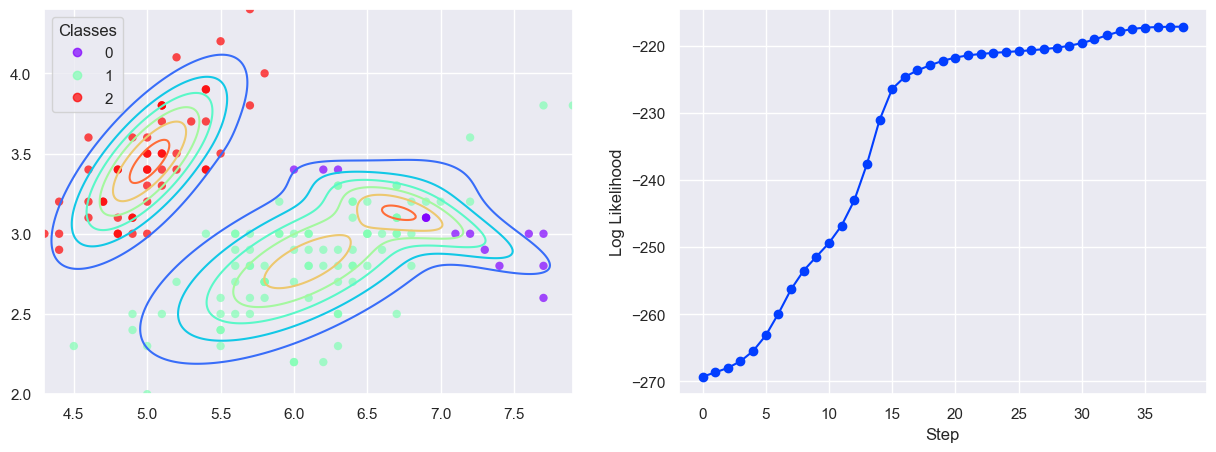

In [8]:
def create_animation(all_steps_em, data_x):
    
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15,5))
    
    log_likelihoods = list(map(lambda x: x[3], all_steps_em))
    
    def animate(i):
        ax.cla()
        ax2.cla()
        
        predictions = all_steps_em[i][4]
        
        plot1 = plot_gaussian_mixtures(all_steps_em[i][0], all_steps_em[i][1], all_steps_em[i][2], iris_x, predictions, target=ax)
                
        ax2.plot(list(range(i)), log_likelihoods[:i], '-o')
        plt.xlabel('Step')
        plt.ylabel('Log Likelihood')
        return plot1
    
    anim = FuncAnimation(
        fig, animate,
        frames=len(all_steps_em), interval=500, blit=True
    )
    return HTML(anim.to_html5_video())

create_animation(all_steps_em, iris_x)

### 1.2) Nearest Centroid-based classification

Write the `nearest_centroid_based_class` that takes (a possibly D-dimensional) data point `x`, a set of (a possibly D-dimensional) means `mus` and (a set of DxD dimensional) `covariances` and returns the predicted class of this data point based on nearest centroid based classification.

In [9]:
def nearest_centroid_based_class(x, mus, covariances):
    x = np.array(x)
    mus = np.array(mus)
    
    distances = []
    for i in range(len(mus)):
        diff = x - mus[i]
        distance = np.dot(np.dot(diff, np.linalg.inv(covariances[i])), diff.T)
        distances.append(distance)
    
    return np.argmin(distances)  


/var/folders/65/1n30j6qx5qg79xwsb8vr4v1c0000gn/T/ipykernel_701/744847111.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))
/var/folders/65/1n30j6qx5qg79xwsb8vr4v1c0000gn/T/ipykernel_701/744847111.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


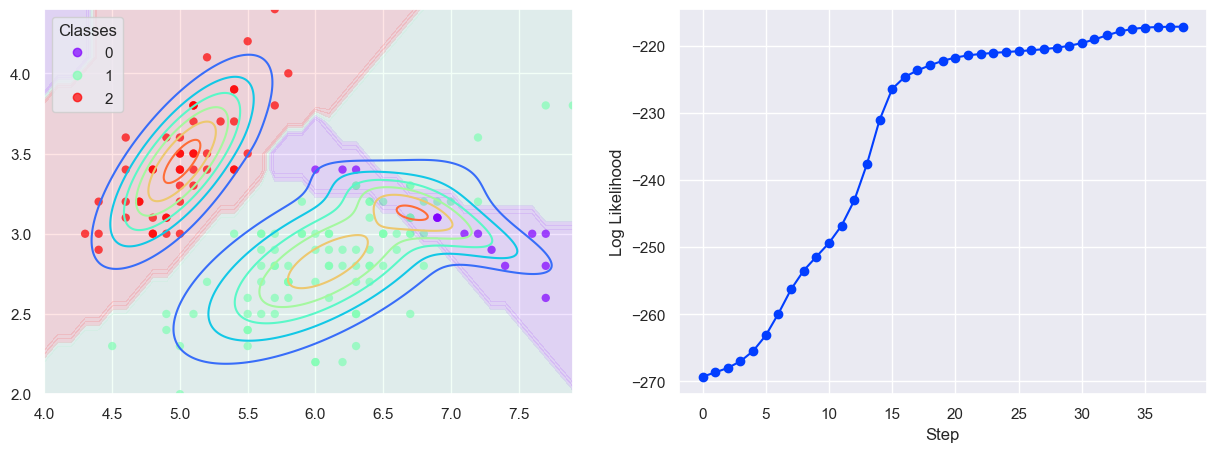

In [10]:
def create_animation(all_steps_em, data_x):
    
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15,5))
    
    log_likelihoods = list(map(lambda x: x[3], all_steps_em))
    
    def animate(i):
        ax.cla()
        ax2.cla()
        
        predictions = all_steps_em[i][4]
        
        plot1 = plot_gaussian_mixtures(all_steps_em[i][0], all_steps_em[i][1], all_steps_em[i][2], iris_x, predictions, target=ax)
        
        plot_mesh(
            lambda x: nearest_centroid_based_class(x, all_steps_em[i][0], all_steps_em[i][1]),
            n_class=len(all_steps_em[i][0]), target=ax
        )
        
        ax2.plot(list(range(i)), log_likelihoods[:i], '-o')
        plt.xlabel('Step')
        plt.ylabel('Log Likelihood')
        return plot1
    
    anim = FuncAnimation(
        fig, animate,
        frames=len(all_steps_em), interval=500, blit=True
    )
    return HTML(anim.to_html5_video())

create_animation(all_steps_em, iris_x)

## 2) Principal Component Analysis

### 2.1) Generate data

In [36]:
iris4_x = np.array(iris.data[:, :4])

def plot_classes_3d(data, classes):

    from mpl_toolkits.mplot3d import Axes3D
    from mpl_toolkits.mplot3d import proj3d

    fig = plt.figure(1, figsize=(8, 6))
    ax = Axes3D(fig, elev=-150, azim=110)
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=classes,
               cmap=plt.cm.Set1, edgecolor='k', s=40)
    plt.show()
plot_classes_3d(iris4_x[:, :3], iris_t)

<Figure size 800x600 with 0 Axes>

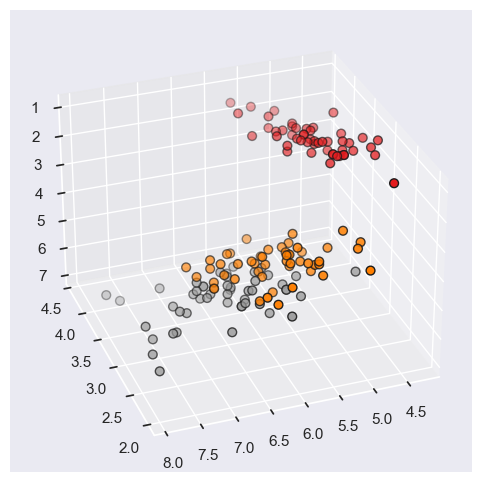

In [50]:
iris4_x = np.array(iris.data[:, :4])

def plot_classes_3d(data, classes):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection='3d')
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=classes,
               cmap=plt.cm.Set1, edgecolor='k', s=40)
    ax.view_init(-150, 110, 0)
    plt.show()
plot_classes_3d(iris4_x[:, :3], iris_t)

### 2.3) Apply PCA

write a function `pca_projection` that takes input data points `data`, desired number of `components` as arguments and returns the PCA projection of the `data`.

In [51]:
def pca_projection(data, components):
    data = np.array(data)
    centered_data = data - np.mean(data, axis= 0)
    covariance_matrix = np.cov(centered_data.T)

    eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
    
    # Sort the eigenvalues in descending order and get the indices
    sorted_indices = np.argsort(eigenvalues)[::-1]

    # Sort eigenvalues
    sorted_eigenvalues = eigenvalues[sorted_indices]

    # Sort eigenvectors according to the sorted eigenvalues
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    U_k = sorted_eigenvectors[:, :components]


    projected_data = centered_data @ U_k

    return projected_data  #sorted_eigenvalues ## if you need to return variance




### 2.4) Display projection

(<matplotlib.collections.PathCollection at 0x134ef6f50>,
 <matplotlib.legend.Legend at 0x134affd10>)

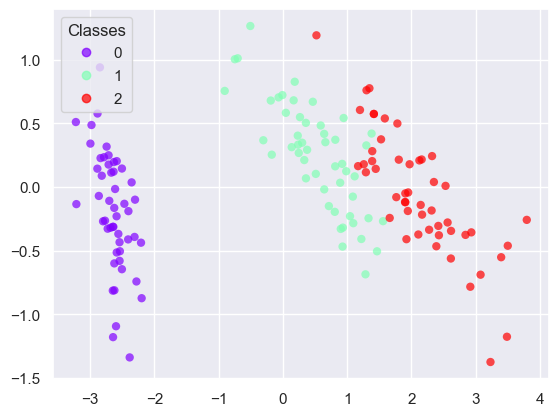

In [52]:
def plot_classes(data, classes, legend=True, target=plt):
    scatter = target.scatter(data[:, 0], data[:, 1], c=classes, alpha=0.7, cmap='rainbow', edgecolor='none')
    if legend:
        legend = target.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
        return (scatter, legend)
    return (scatter, )

projected_data = pca_projection(iris4_x, 2)
plot_classes(projected_data, iris_t)

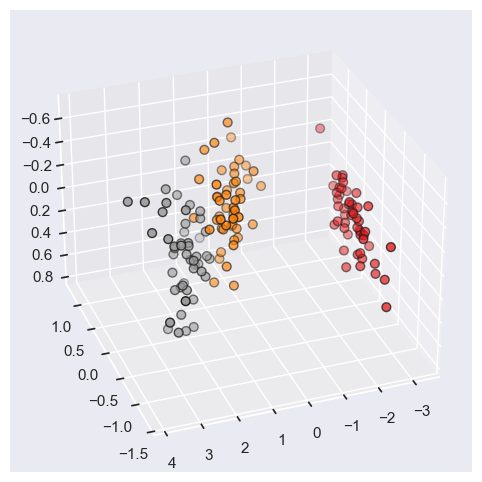

In [53]:
projected_data = pca_projection(iris4_x, 3)
plot_classes_3d(projected_data, iris_t)

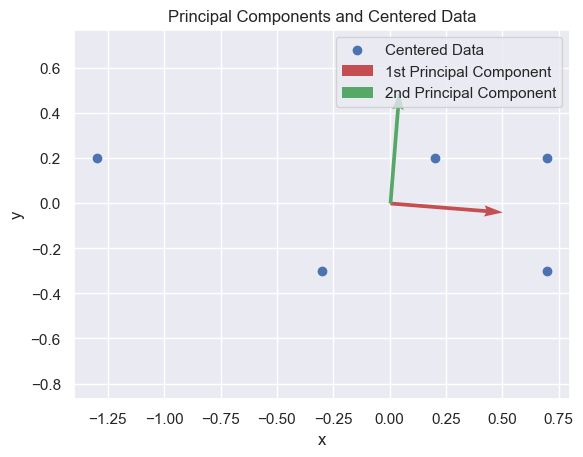

In [6]:

hej = np.array([[-1, 1], [0.5, 1], [1, 1], [0, 0.5], [1, 0.5]])


# Using the provided function to perform PCA and obtain the principal components
def pca_projection(data, components):
    data = np.array(data)
    centered_data = data - np.mean(data, axis= 0)
    covariance_matrix = np.cov(centered_data.T)

    eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
    
    # Sort the eigenvalues in descending order and get the indices
    sorted_indices = np.argsort(eigenvalues)[::-1]

    # Sort eigenvalues
    sorted_eigenvalues = eigenvalues[sorted_indices]

    # Sort eigenvectors according to the sorted eigenvalues
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    U_k = sorted_eigenvectors[:, :components]

    projected_data = centered_data @ U_k

    return projected_data, sorted_eigenvectors  # Returning the sorted eigenvectors for plotting

# Perform PCA using the provided function
projected_data, sorted_eigenvectors = pca_projection(hej, 2)

_, sorted_eigenvectors = pca_projection(hej, 2)

# Center the data for plotting
centered_data = hej - np.mean(hej, axis=0)

arrow_scale = 0.5  # To make the arrows shorter

plt.scatter(centered_data[:, 0], centered_data[:, 1], c='b', label='Centered Data')
plt.quiver(0, 0, sorted_eigenvectors[0, 0] * arrow_scale, sorted_eigenvectors[1, 0] * arrow_scale, angles='xy', scale_units='xy', scale=1, color='r', label='1st Principal Component')
plt.quiver(0, 0, sorted_eigenvectors[0, 1] * arrow_scale, sorted_eigenvectors[1, 1] * arrow_scale, angles='xy', scale_units='xy', scale=1, color='g', label='2nd Principal Component')
plt.axis('equal')
plt.legend()
plt.title('Principal Components and Centered Data')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()
